# Maximum Likelihood Estimation.

## Libraries and Data.


### Importing the libraries.


In [1]:
from itertools import chain

from anndata import AnnData
from matplotlib import rcParams
import matplotlib.pyplot as plt
import numpy as np
import scanpy as sc
import seaborn as sns
from scipy.stats import norm
from scipy import special
import torch
from tqdm import tqdm

from sc_exp_design.data import DataManager, SequentialDataLoader
from sc_exp_design.sym import GaussianMixtureModel

# defining figure size
FIGSIZE = (3, 3)
rcParams["figure.figsize"] = FIGSIZE


### Reading the data.


In [2]:
PATH = "../../theis/HID01_fcs_concatenated.h5ad"
adata = sc.read_h5ad(PATH)
adata


AnnData object with n_obs × n_vars = 93278696 × 21
    obs: 'replicate', 'date', 'cytometer', 'cytometer_serial_no', 'well_id', 'count_beads', 'experiment_number', 'experiment_id', 'mtg_[µm]', 'rhflt3l_[ng/ml]', 'gm-csf_[ng/ml]', 'tpo_[ng/ml]', 'sr1_[nm]', 'um171_[nm]', 'um729_[µm]', 'scf_[ng/ml]', 'butyzamide_[nm]', 'retinoic_acid_[µm]', 'ldl_[ng/ml]', 'il3_[ng/ml]', 'source_id', 'hydrogel_type', 'o2_[%]', 'source_cell_phenotype', 'total_count_beads', 'counts_source_cell_phenotype', 'days_of_culture', 'plate', 'absolute_number_multiplier_[2^n]', 'cytometer_id', 'FSC - Area', 'FSC - Height', 'FSC - Width', 'SSC - Area', 'SSC - Height', 'SSC - Width', 'Time Stamp', 'batch'
    var: 'n', 'channel', 'marker', 'PnD', 'PnB', 'PnR', 'PnG', 'PnE', 'signal_type', 'antibody'
    uns: 'meta'

### Subsampling the data.


In [3]:
# optionally subsample the data
KEEP_COPY = True
SUBSAMPLE = True
SUBSAMPLING_DONE = False
SUBSAMPLE_SIZE = 1e-2

if SUBSAMPLE and not SUBSAMPLING_DONE:
    if KEEP_COPY:
        adata_original = adata.copy()
        sc.pp.subsample(adata, SUBSAMPLE_SIZE)
    SUBSAMPLING_DONE = True
adata


AnnData object with n_obs × n_vars = 932786 × 21
    obs: 'replicate', 'date', 'cytometer', 'cytometer_serial_no', 'well_id', 'count_beads', 'experiment_number', 'experiment_id', 'mtg_[µm]', 'rhflt3l_[ng/ml]', 'gm-csf_[ng/ml]', 'tpo_[ng/ml]', 'sr1_[nm]', 'um171_[nm]', 'um729_[µm]', 'scf_[ng/ml]', 'butyzamide_[nm]', 'retinoic_acid_[µm]', 'ldl_[ng/ml]', 'il3_[ng/ml]', 'source_id', 'hydrogel_type', 'o2_[%]', 'source_cell_phenotype', 'total_count_beads', 'counts_source_cell_phenotype', 'days_of_culture', 'plate', 'absolute_number_multiplier_[2^n]', 'cytometer_id', 'FSC - Area', 'FSC - Height', 'FSC - Width', 'SSC - Area', 'SSC - Height', 'SSC - Width', 'Time Stamp', 'batch'
    var: 'n', 'channel', 'marker', 'PnD', 'PnB', 'PnR', 'PnG', 'PnE', 'signal_type', 'antibody'
    uns: 'meta'

### Applying Tranformation.


In [4]:
cofactor = 100
key_arcsin = f"X_arcsinh_cof{cofactor}" 
adata.obsm[key_arcsin] = np.arcsinh(adata.X/cofactor)
adata


AnnData object with n_obs × n_vars = 932786 × 21
    obs: 'replicate', 'date', 'cytometer', 'cytometer_serial_no', 'well_id', 'count_beads', 'experiment_number', 'experiment_id', 'mtg_[µm]', 'rhflt3l_[ng/ml]', 'gm-csf_[ng/ml]', 'tpo_[ng/ml]', 'sr1_[nm]', 'um171_[nm]', 'um729_[µm]', 'scf_[ng/ml]', 'butyzamide_[nm]', 'retinoic_acid_[µm]', 'ldl_[ng/ml]', 'il3_[ng/ml]', 'source_id', 'hydrogel_type', 'o2_[%]', 'source_cell_phenotype', 'total_count_beads', 'counts_source_cell_phenotype', 'days_of_culture', 'plate', 'absolute_number_multiplier_[2^n]', 'cytometer_id', 'FSC - Area', 'FSC - Height', 'FSC - Width', 'SSC - Area', 'SSC - Height', 'SSC - Width', 'Time Stamp', 'batch'
    var: 'n', 'channel', 'marker', 'PnD', 'PnB', 'PnR', 'PnG', 'PnE', 'signal_type', 'antibody'
    uns: 'meta'
    obsm: 'X_arcsinh_cof100'

### Initializing DataManager

In [5]:
# data manager
datamanager = DataManager(
    adata,
    sample_rep=key_arcsin
)
data = datamanager.get_data()


### Defining DataLoader.

In [6]:
# data loading
BATCH_SIZE = 2048
dataloader = SequentialDataLoader(
    data,
    batch_size=BATCH_SIZE,
)


## MLE of GMM model.

### Defining various setting that we need.

In [16]:
# settings
DIM = adata.X.shape[1]
N_COMPS = 5


### Initializing the Parameters.

In [17]:
homoskedastic = False
constan_weights = True
weights = torch.nn.Parameter(
    torch.randn(N_COMPS, 1 if constan_weights else DIM, requires_grad=True, device="cuda")
)
means = torch.nn.Parameter(
    torch.randn(N_COMPS, DIM, requires_grad=True, device="cuda")
)
covs = torch.nn.Parameter(
    torch.randn(N_COMPS, 1 if homoskedastic else DIM, requires_grad=True, device="cuda")
)
means.shape, covs.shape, weights.shape


(torch.Size([5, 21]), torch.Size([5, 21]), torch.Size([5, 1]))

### Optimizing the Parameters.

loss: 28.060543060302734: 100%|█████████▉| 1999/2000 [00:13<00:00, 439.94it/s]

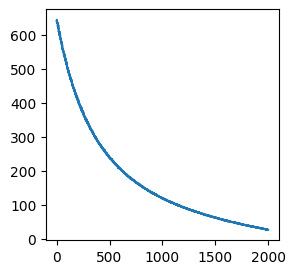

In [18]:
# defining optimizer
optimizer = torch.optim.Adam(
    [
        weights, means, covs
    ]
    , lr=1e-3
)

# iteration
n_grad_steps = 2_000
iterator = range(n_grad_steps)
pbar = tqdm(iterator)

# storing progress
rec_loss_history = np.zeros((n_grad_steps, ))
reg_loss_history = np.zeros((n_grad_steps, ))
loss_history = np.zeros((n_grad_steps, ))


# iterating over gradient steps
for grad_step in iterator:
    # sampling
    states = dataloader.sample()["state_data"]
    states = states.repeat(N_COMPS, 1, 1)

    # handling shapes
    mean = means.unsqueeze(1).repeat(1, BATCH_SIZE, 1)
    cov = covs.unsqueeze(1).repeat(1, BATCH_SIZE, 1)
    weight = weights.unsqueeze(1).repeat(1, BATCH_SIZE, 1)

    # computing activation on weights and covariance
    cov = torch.nn.functional.softplus(cov)**2
    weight = torch.nn.functional.softmax(weight, dim=0)

    # computing likelihood for each component
    if homoskedastic:
        ll = (
            (0.5 / cov) * torch.sum((states - mean) ** 2, axis=-1, keepdim=True)
            + 0.5 * torch.log(cov)
            + DIM * 0.5 * torch.log(torch.tensor([2 * np.pi], device=mean.device))
        )[:, :, 0]

        weight = weight[:, :, 0]
        loss = ((weight.T)@ll).mean()
    else:
        ll = (
            (0.5 / cov) * torch.sum((states - mean) ** 2, axis=-1, keepdim=True)
            + 0.5 * torch.sum(torch.log(cov), dim=-1, keepdim=True)
            + DIM * 0.5 * torch.log(torch.tensor([2 * np.pi], device=mean.device))
        )[:, :, 0]
        
        # Weighted sum over components using mixture weights
        weight = weight[:, :, 0]             # shape: (N_COMPS, BATCH_SIZE)
        ll_weighted = (weight * ll).sum(dim=0)  # shape: (BATCH_SIZE,)
        loss = ll_weighted.mean()  

    # backprop
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    # logging
    pbar.set_description(f"loss: {loss.item()}")
    pbar.update()
    loss_history[grad_step] = loss.item()

# plotting
plt.plot(loss_history)


### Visualizing the learned parameters.

In [19]:
int2antibody = {
    idx: adata.var.iloc[idx][["antibody"]].values[0] for idx in range(adata.var.shape[0])
}
antibody2idx = {v:k for k, v in int2antibody.items()}


0.53066856
0.29105386
0.021254173
0.06777073
0.089252666
0.53066856
0.29105386
0.021254173
0.06777073
0.089252666
0.53066856
0.29105386
0.021254173
0.06777073
0.089252666
0.53066856
0.29105386
0.021254173
0.06777073
0.089252666
0.53066856
0.29105386
0.021254173
0.06777073
0.089252666


loss: 28.060543060302734: 100%|██████████| 2000/2000 [00:33<00:00, 439.94it/s]

0.53066856
0.29105386
0.021254173
0.06777073
0.089252666
0.53066856
0.29105386
0.021254173
0.06777073
0.089252666
0.53066856
0.29105386
0.021254173
0.06777073
0.089252666
0.53066856
0.29105386
0.021254173
0.06777073
0.089252666
0.53066856
0.29105386
0.021254173
0.06777073
0.089252666
0.53066856
0.29105386
0.021254173
0.06777073
0.089252666
0.53066856
0.29105386
0.021254173
0.06777073
0.089252666
0.53066856
0.29105386
0.021254173
0.06777073
0.089252666
0.53066856
0.29105386
0.021254173
0.06777073
0.089252666
0.53066856
0.29105386
0.021254173
0.06777073
0.089252666
0.53066856
0.29105386
0.021254173
0.06777073
0.089252666
0.53066856
0.29105386
0.021254173
0.06777073
0.089252666
0.53066856
0.29105386
0.021254173
0.06777073
0.089252666
0.53066856
0.29105386
0.021254173
0.06777073
0.089252666
0.53066856
0.29105386
0.021254173
0.06777073
0.089252666
0.53066856
0.29105386
0.021254173
0.06777073
0.089252666


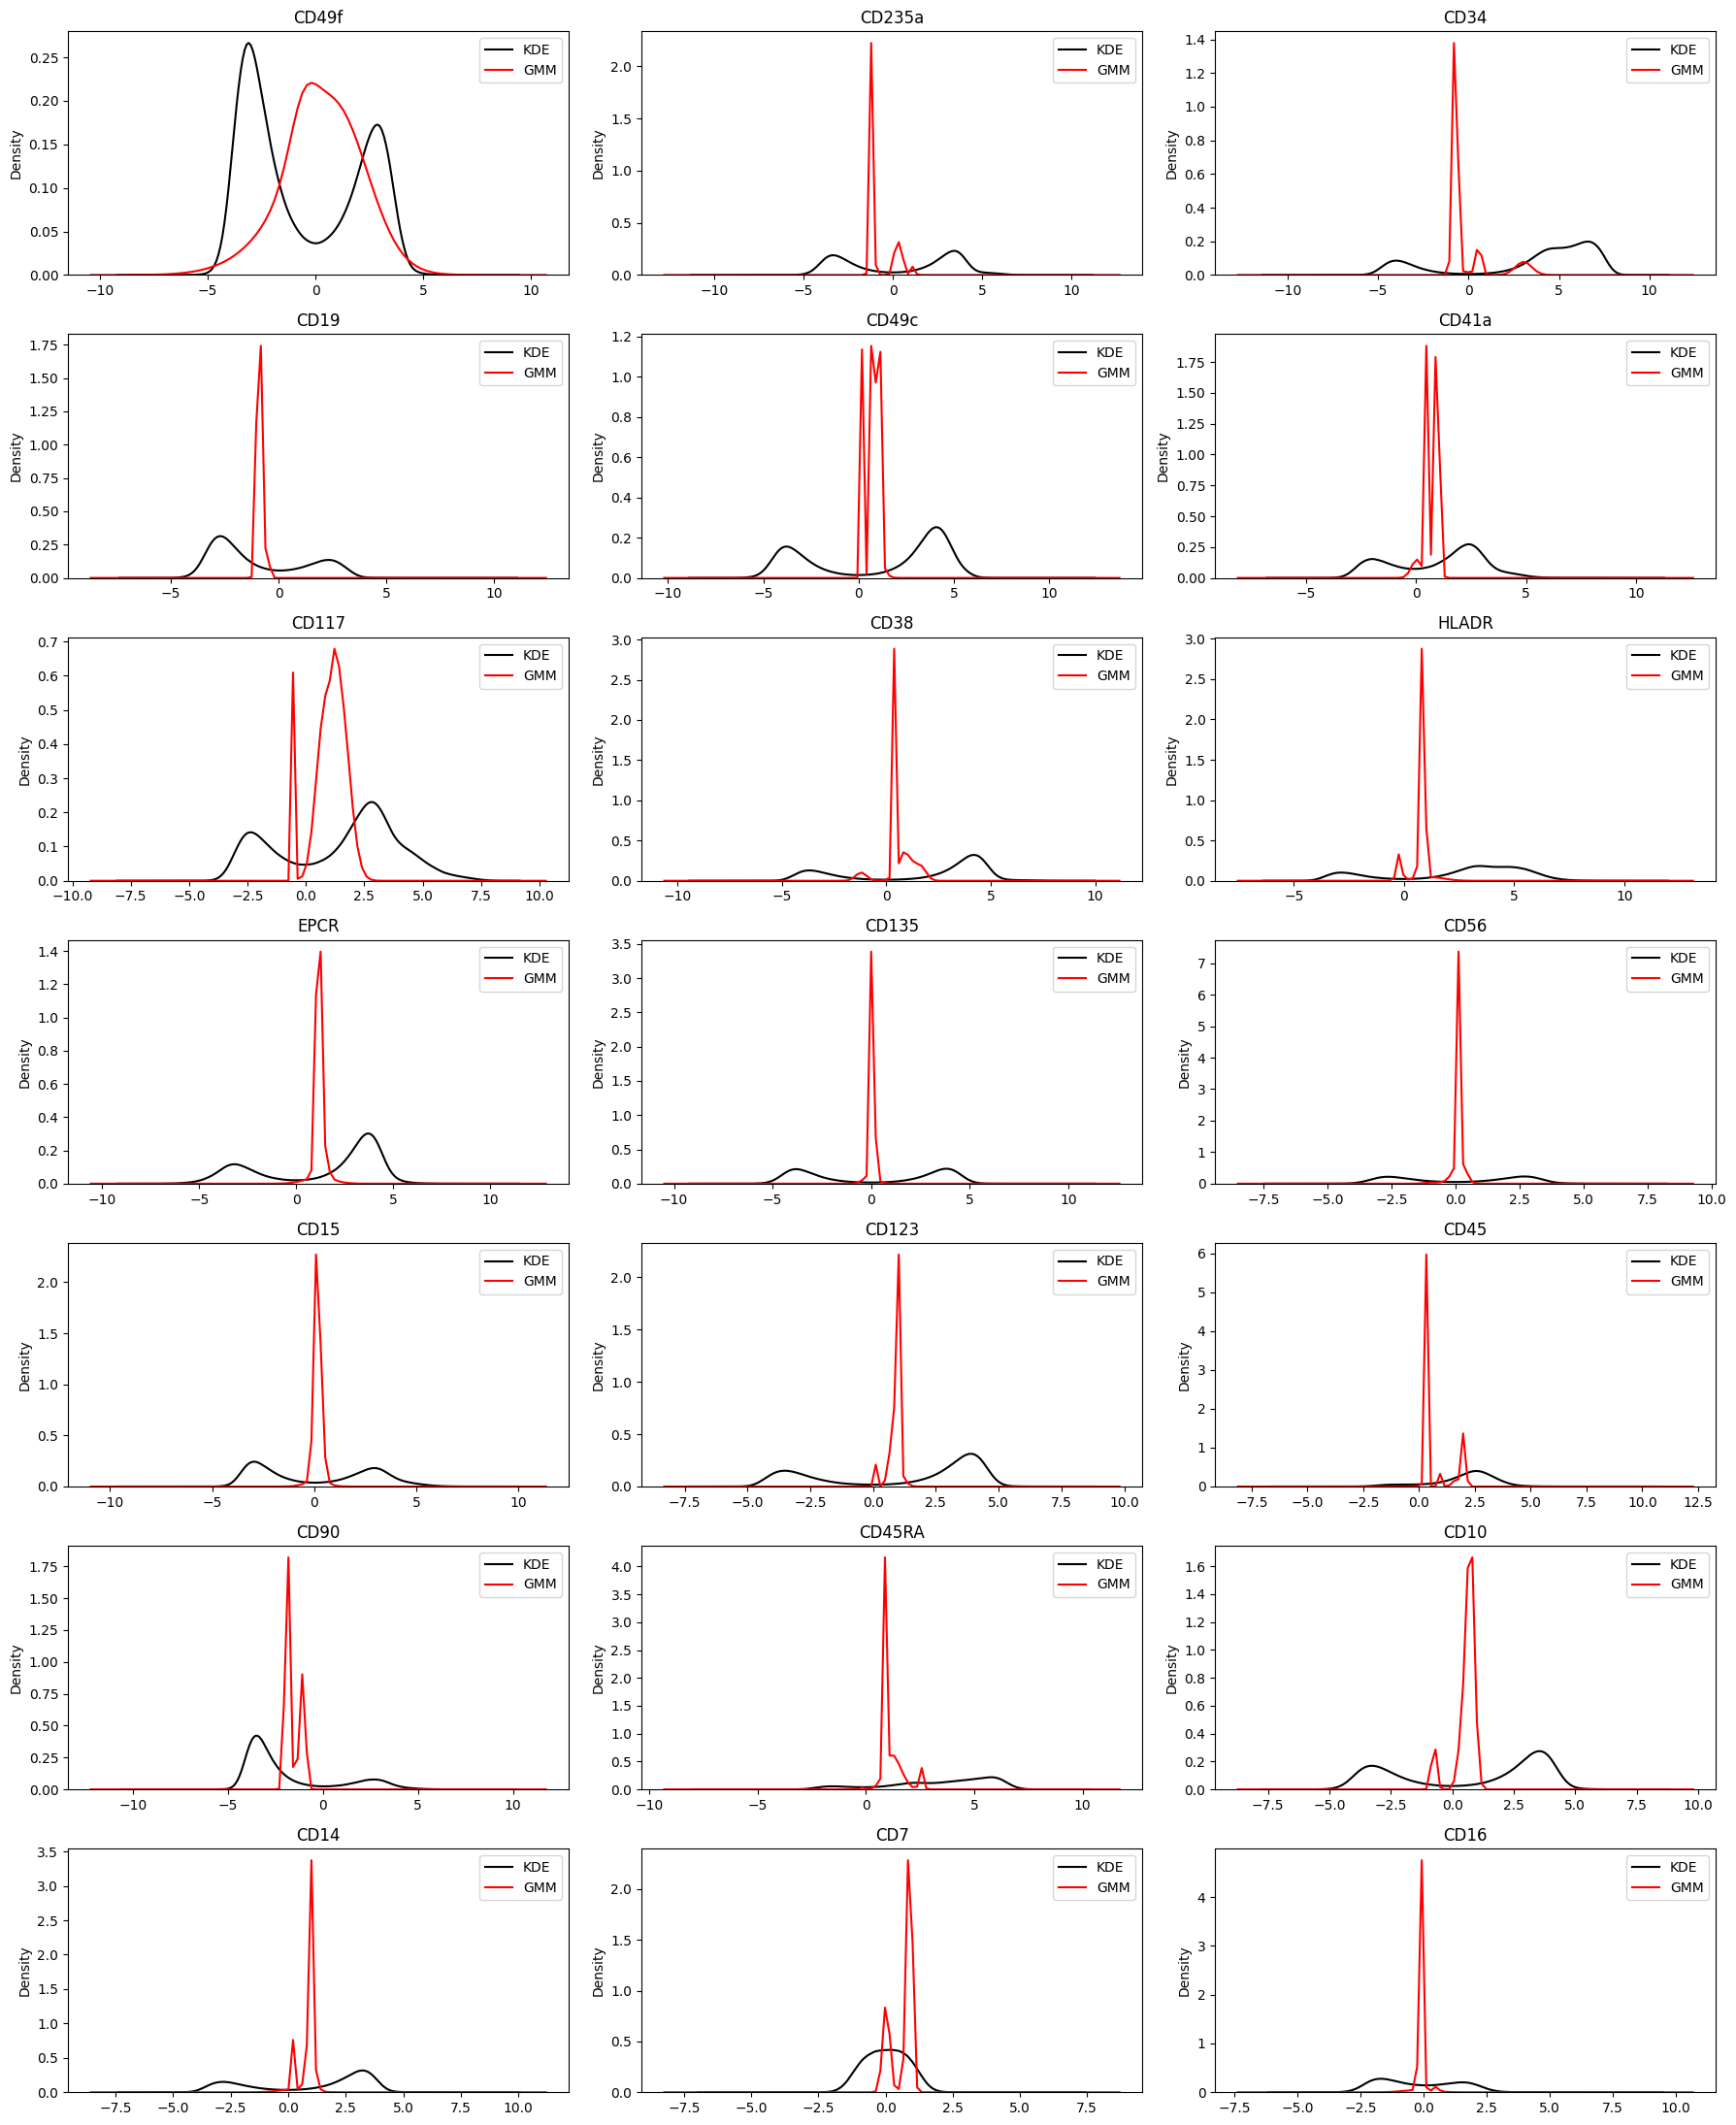

In [20]:
if isinstance(weights, torch.Tensor):
    weights = weights.squeeze().detach().cpu().numpy()    # shape (5,)
    means = means.detach().cpu().numpy()                  # shape (5, 21)
    covs = covs.squeeze().detach().cpu().numpy()          # shape (5,)
weight = special.softmax(weights) 
covs = special.softplus(covs) 
# stds = np.sqrt(covs)[:, None]          # shape (5, 1)

# Your data: shape (N, 21)
# data = torch.randn(1000, 21).numpy()
data = adata.obsm[key_arcsin]
data = data

dims = means.shape[1]  # 21

fig, axs = plt.subplots(7, 3, figsize=(18, 22))
axs = axs.flatten()

for dim in range(dims):
    ax = axs[dim]

    # Define linspace over the data range for this dimension
    data_min = data[:, dim].min()
    data_max = data[:, dim].max()
    padding = 0.1 * (data_max - data_min)
    x_grid = np.linspace(data_min - padding, data_max + padding, 100)

    # KDE from data
    sns.kdeplot(data[:, dim], ax=ax, label='KDE', color='black')

    # GMM density over this dimension
    gmm_density = np.zeros_like(x_grid)
    for k in range(weights.shape[0]):
        w = weight[k]
        mu = means[k, dim]
        sigma = covs[k, dim]
        print(w)
        gmm_density += w * norm.pdf(x_grid, mu, sigma)

    ax.plot(x_grid, gmm_density, label='GMM', color='red')
    ax.set_title(f'{int2antibody[dim]}')
    ax.legend()

# Hide any unused subplots (in case dims < len(axs))
for i in range(dims, len(axs)):
    axs[i].axis('off')

plt.tight_layout()
plt.show()
